In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns


In [2]:
# load our data 
df=pd.read_csv(r"C:\Users\Dell\Desktop\data.csv",encoding='latin1')
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


Basic Ques

In [3]:
# What is the shape of the dataset?
print(df.shape)
# numbers of row 
print("numbers of row",df.shape[0])

(541909, 8)
numbers of row 541909


In [4]:
# What are the data types of each column?
df.info()
# df.dtypes

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [5]:
# How many missing values are present in each column?
print(df.isna().sum())

print(f"Description column have {df['Description'].isna().sum()} missing values")
print(f"CustomerID column have {df['CustomerID'].isna().sum()} missing values")

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
Description column have 1454 missing values
CustomerID column have 135080 missing values


In [6]:
# How many duplicate records exist in the dataset?
print(df.duplicated().sum())
# How many unique customers are there?
print("unique customers ",df['CustomerID'].nunique())
# How many unique products are there?
print("unique products",df['StockCode'].nunique())
# How many countries are represented in the dataset?
df['Country'].nunique()
# What is the date range covered by the dataset?
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
print("Start date ",df['InvoiceDate'].min())
print("End date",df['InvoiceDate'].max())

5268
unique customers  4372
unique products 4070
Start date  2010-12-01 08:26:00
End date 2011-12-09 12:50:00


Data Cleaning

In [7]:
# Which columns contain missing values, and what percentage of data is missing in each column?
missing_value=df.isnull().sum()
noOfRow=len(df)
missing_percent=(missing_value*100)/(noOfRow)
missing_percent[missing_percent>0]
# df[['Description','CustomerID']].isna().sum()
# How many transactions have negative quantities or prices?
df[df['Quantity']<0].shape[0]
# Are there any invalid or cancelled orders in the dataset
print("total cancelled order",df[df['InvoiceNo'].astype(object).str.startswith('C')].shape[0])


total cancelled order 9288


In [8]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [9]:
# total revenue 

Visulization 

<Axes: ylabel='Description'>

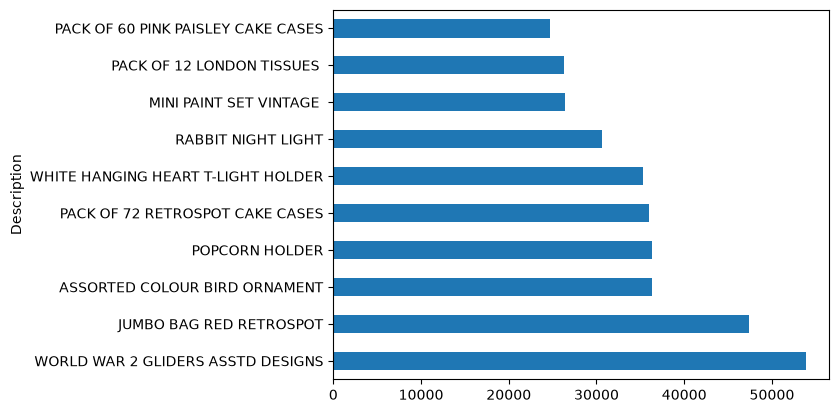

In [10]:
# Top 10 best-selling products by quantity
bestSelling=df.groupby(by='Description')['Quantity'].sum().sort_values(ascending=False).head(10)
bestSelling.plot(kind='barh')

<Axes: ylabel='Description'>

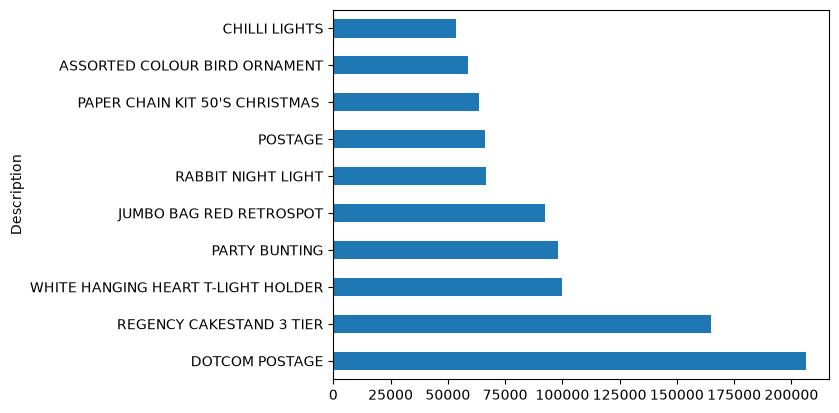

In [11]:
# Top 10 products by revenue
df['Revenue']=df['Quantity']*df['UnitPrice']
byrevenue=df.groupby(by='Description')['Revenue'].sum().sort_values(ascending=False).head(10)
byrevenue.plot(kind='barh')


<Axes: >

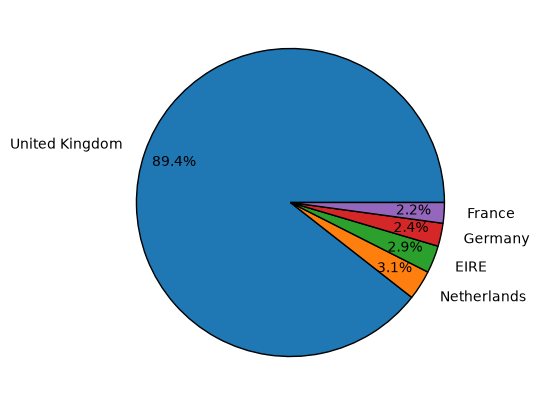

In [46]:
# Revenue contribution by top 5 countries
top10=df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head()
top10.plot(kind='pie',autopct='%1.1f%%',figsize=(8,5),pctdistance=0.8,labeldistance=1.15,wedgeprops={'edgecolor':'black','linewidth':1})

In [48]:
pd.read_csv(r"C:\Users\Dell\Desktop\compressed_data.csv")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12-09-2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12-09-2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12-09-2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12-09-2011 12:50,4.15,12680.0,France
